# COVID-19 Global Trends Analysis
**Analyst:** Varshini Karuppusamy  
**Dataset:** Our World in Data — COVID-19 Complete Dataset  
**Source:** https://github.com/owid/covid-19-data  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---

## Project Overview
This project analyzes global COVID-19 trends across 200+ countries using the
Our World in Data dataset — one of the most comprehensive and trusted public
health datasets available. The analysis covers cases, deaths, vaccination
progress, and wave patterns using time-series techniques.

## Business Questions
1. Which countries had the highest total cases and deaths?
2. How did COVID-19 waves develop over time globally?
3. What is the case fatality rate by country?
4. How did vaccination progress differ across countries?
5. Is there a relationship between vaccination rates and death rates?
6. Which regions recovered fastest?

---

## DAY 1 — Setup & Data Acquisition
**Goal:** Load dataset, understand structure, check quality  


In [1]:
# Install libraries if needed
!pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [2]:
# ─────────────────────────────────────────────────────────
# DATASET: Our World in Data COVID-19
# The notebook loads it directly from GitHub — no manual
# download needed! If internet is unavailable it falls back
# to a local copy.
# ─────────────────────────────────────────────────────────

URL = ('https://raw.githubusercontent.com/owid/covid-19-data'
       '/master/public/data/owid-covid-data.csv')

try:
    print('Downloading dataset from Our World in Data...')
    df = pd.read_csv(URL, low_memory=False)
    df.to_csv('owid-covid-data.csv', index=False)   # save local copy
    print('✅ Downloaded and saved locally!')
except Exception:
    print('Loading from local copy...')
    df = pd.read_csv('owid-covid-data.csv', low_memory=False)

print(f'\nRows: {len(df):,} | Columns: {df.shape[1]}')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
print(f'Countries/regions: {df["location"].nunique()}')

✅ Downloaded and saved locally!

Rows: 429,435 | Columns: 67
Date range: 2020-01-01 → 2024-08-14
Countries/regions: 255


In [3]:
# Preview key columns
key_cols = [
    'location','continent','date',
    'total_cases','new_cases','new_cases_smoothed',
    'total_deaths','new_deaths','new_deaths_smoothed',
    'total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','population'
]
print('Key columns available:')
for c in key_cols:
    exists = '✅' if c in df.columns else '❌'
    print(f'  {exists} {c}')

Key columns available:
  ✅ location
  ✅ continent
  ✅ date
  ✅ total_cases
  ✅ new_cases
  ✅ new_cases_smoothed
  ✅ total_deaths
  ✅ new_deaths
  ✅ new_deaths_smoothed
  ✅ total_vaccinations
  ✅ people_vaccinated
  ✅ people_fully_vaccinated
  ✅ population


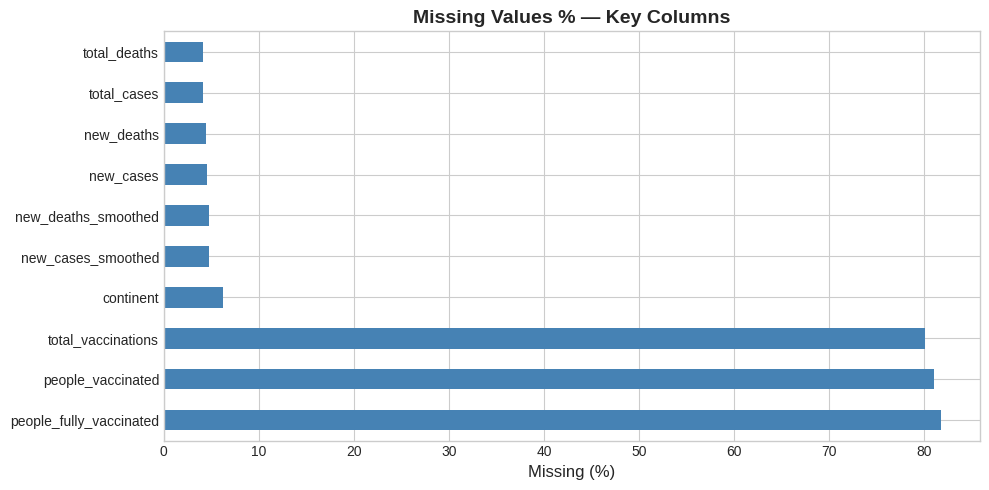

Vaccination columns have high missing % — expected, as data collection started later.


In [4]:
# Missing value overview (key columns only)
missing = (df[key_cols].isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
missing.plot(kind='barh', ax=ax, color='steelblue')
plt.title('Missing Values % — Key Columns', fontweight='bold')
plt.xlabel('Missing (%)')
plt.tight_layout()
plt.savefig('fig01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vaccination columns have high missing % — expected,',
      'as data collection started later.')

---
## DAY 2 — Data Cleaning & Preparation
**Goal:** Filter real countries, fix dates, create analysis-ready features  


In [5]:
# The dataset includes continental/global aggregates — remove them
# Real countries have a continent value; aggregates do not
aggregates = [
    'World','Africa','Asia','Europe','European Union',
    'North America','Oceania','South America',
    'High income','Low income','Lower middle income',
    'Upper middle income','International'
]
df_countries = df[~df['location'].isin(aggregates)].copy()
df_countries = df_countries[df_countries['continent'].notna()].copy()

# Parse dates
df_countries['date'] = pd.to_datetime(df_countries['date'])
df_countries['year']  = df_countries['date'].dt.year
df_countries['month'] = df_countries['date'].dt.month
df_countries['year_month'] = df_countries['date'].dt.to_period('M')

# Per-million metrics for fair country comparison
df_countries['cases_per_million']  = (
    df_countries['total_cases'] / df_countries['population'] * 1_000_000)
df_countries['deaths_per_million'] = (
    df_countries['total_deaths'] / df_countries['population'] * 1_000_000)
df_countries['vacc_pct'] = (
    df_countries['people_fully_vaccinated'] /
    df_countries['population'] * 100)

print(f'✅ Clean dataset: {len(df_countries):,} rows')
print(f'   Countries: {df_countries["location"].nunique()}')
print(f'   Date range: {df_countries["date"].min().date()}',
      f'→ {df_countries["date"].max().date()}')

✅ Clean dataset: 402,910 rows
   Countries: 243
   Date range: 2020-01-01 → 2024-08-14


In [6]:
# Build a "latest snapshot" table — most recent record per country
latest = (
    df_countries
    .sort_values('date')
    .groupby('location')
    .last()
    .reset_index()
)
latest = latest[latest['total_cases'].notna() &
                (latest['total_cases'] > 0)].copy()

# Case Fatality Rate
latest['cfr'] = (latest['total_deaths'] / latest['total_cases'] * 100).round(2)

print(f'Countries with valid case data: {len(latest)}')
print(f'\nGlobal totals:')
print(f'  Total cases:  {latest["total_cases"].sum():,.0f}')
print(f'  Total deaths: {latest["total_deaths"].sum():,.0f}')
print(f'  Global CFR:   {latest["total_deaths"].sum()/latest["total_cases"].sum()*100:.2f}%')

Countries with valid case data: 232

Global totals:
  Total cases:  775,866,783
  Total deaths: 7,057,132
  Global CFR:   0.91%


---
## DAY 3 — Cases & Deaths Analysis
**Goal:** Identify top-affected countries, visualize global burden  


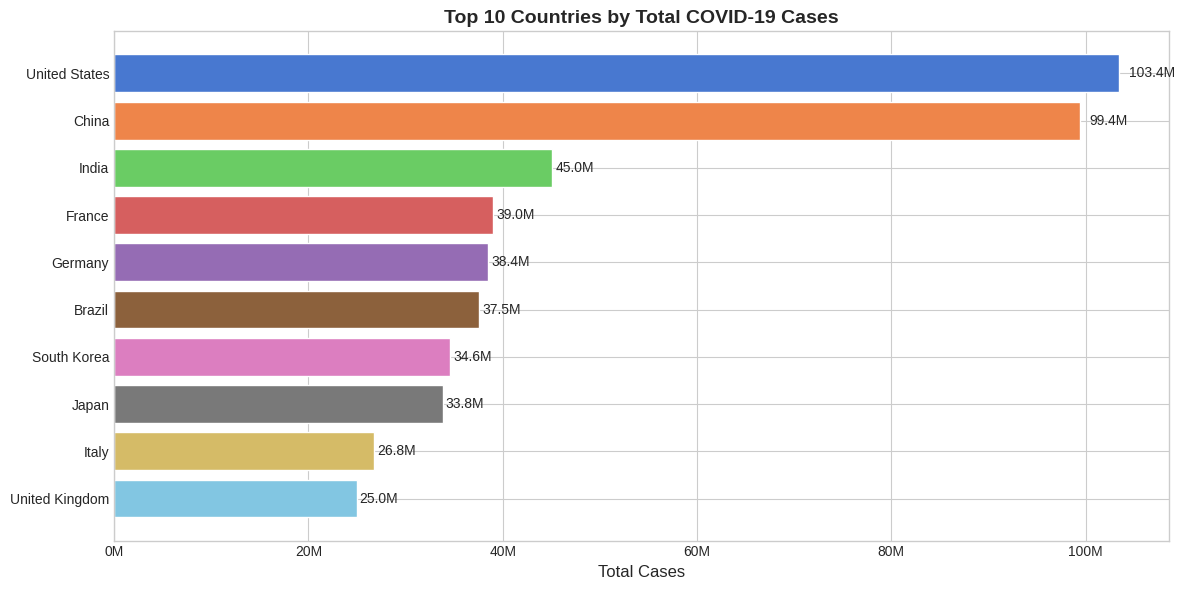

In [7]:
# Top 10 Countries — Total Cases
top10_cases = latest.nlargest(10, 'total_cases')[['location','total_cases','continent']]

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('muted', len(top10_cases))
bars = ax.barh(top10_cases['location'], top10_cases['total_cases'],
               color=colors, edgecolor='white')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
for bar, val in zip(bars, top10_cases['total_cases']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=10)
plt.title('Top 10 Countries by Total COVID-19 Cases',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Cases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig02_top10_cases.png', dpi=150, bbox_inches='tight')
plt.show()

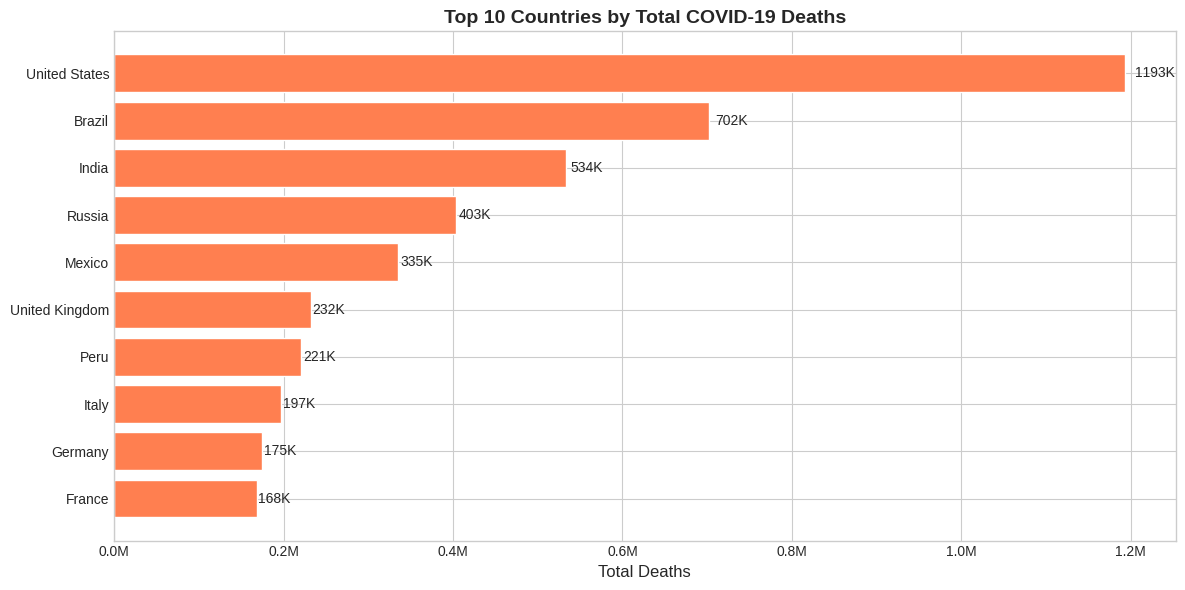

In [8]:
# Top 10 Countries — Total Deaths
top10_deaths = latest.nlargest(10, 'total_deaths')[['location','total_deaths','continent']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_deaths['location'], top10_deaths['total_deaths'],
               color='coral', edgecolor='white')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, top10_deaths['total_deaths']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val/1e3:.0f}K', va='center', fontsize=10)
plt.title('Top 10 Countries by Total COVID-19 Deaths',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Deaths')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig03_top10_deaths.png', dpi=150, bbox_inches='tight')
plt.show()

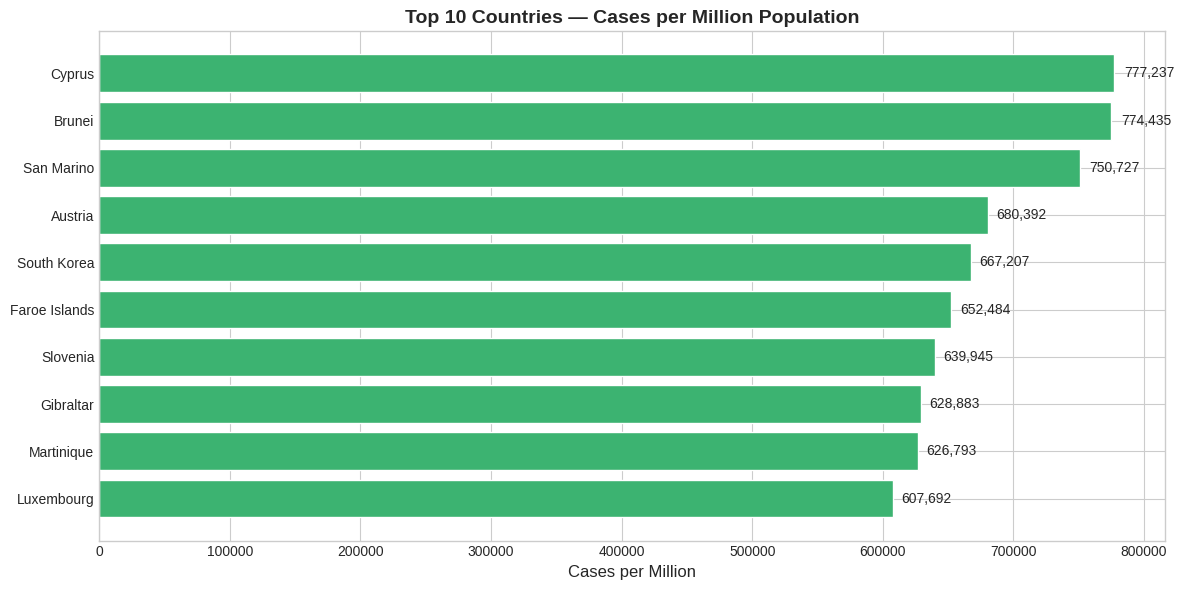

Note: Per-million metric removes population size bias — small countries rank higher here than in total case counts.


In [9]:
# Cases per Million — fairer comparison (removes population bias)
top10_per_million = latest.nlargest(10, 'cases_per_million')[
    ['location','cases_per_million','continent']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_per_million['location'],
               top10_per_million['cases_per_million'],
               color='mediumseagreen', edgecolor='white')
for bar, val in zip(bars, top10_per_million['cases_per_million']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10)
plt.title('Top 10 Countries — Cases per Million Population',
          fontsize=14, fontweight='bold')
plt.xlabel('Cases per Million')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig04_cases_per_million.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Per-million metric removes population size bias —',
      'small countries rank higher here than in total case counts.')

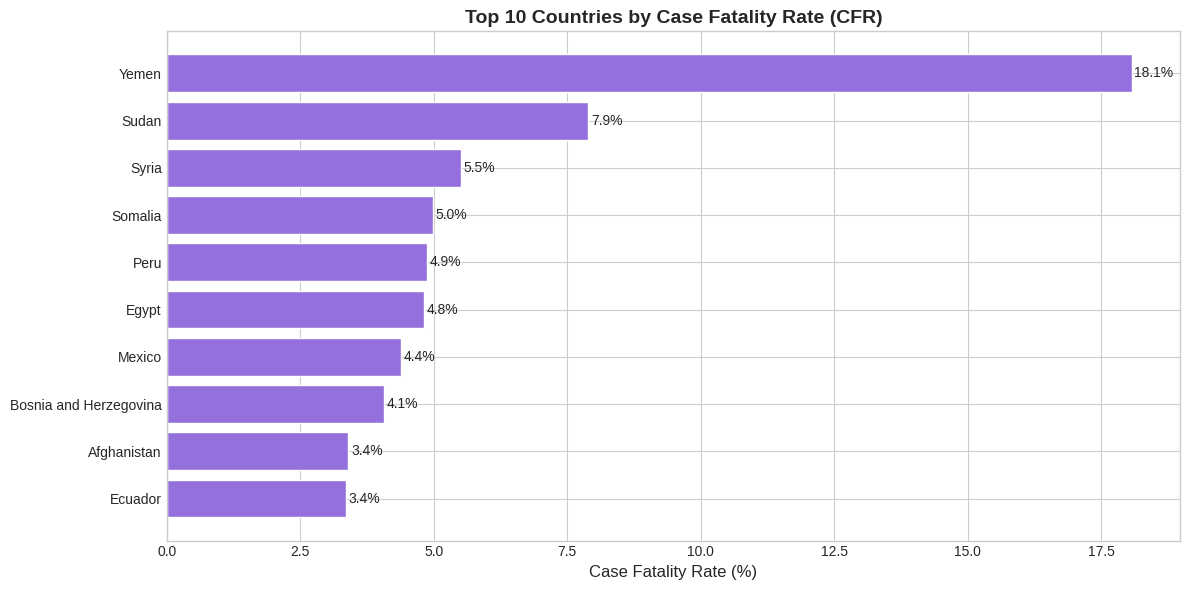

In [10]:
# Case Fatality Rate — Top 10 highest CFR countries
cfr_df = latest[latest['total_cases'] > 10000].nlargest(10, 'cfr')[
    ['location','cfr','total_cases','total_deaths']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cfr_df['location'], cfr_df['cfr'],
               color='mediumpurple', edgecolor='white')
for bar, val in zip(bars, cfr_df['cfr']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.title('Top 10 Countries by Case Fatality Rate (CFR)',
          fontsize=14, fontweight='bold')
plt.xlabel('Case Fatality Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig05_cfr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## DAY 4 — Wave Pattern Analysis (Time Series)
**Goal:** Visualize COVID waves using rolling averages  


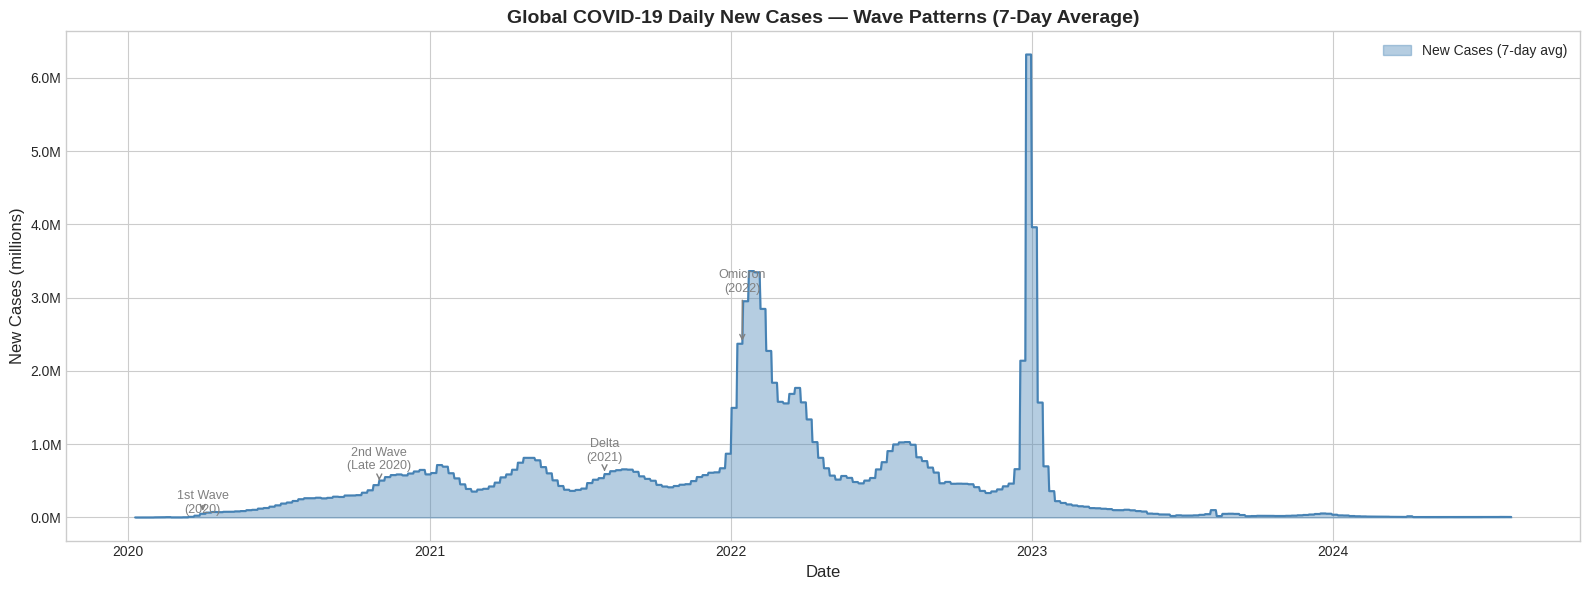

In [11]:
# Global daily new cases — world aggregate
world = df[df['location'] == 'World'][['date','new_cases_smoothed',
                                        'new_deaths_smoothed']].copy()
world['date'] = pd.to_datetime(world['date'])
world = world.dropna(subset=['new_cases_smoothed'])

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(world['date'], world['new_cases_smoothed'],
                alpha=0.4, color='steelblue', label='New Cases (7-day avg)')
ax.plot(world['date'], world['new_cases_smoothed'],
        color='steelblue', linewidth=1.5)

# Annotate major waves
waves = {
    '1st Wave\n(2020)':  '2020-04-01',
    '2nd Wave\n(Late 2020)': '2020-11-01',
    'Delta\n(2021)':    '2021-08-01',
    'Omicron\n(2022)':  '2022-01-15',
}
for label, date in waves.items():
    d = pd.to_datetime(date)
    if d in world['date'].values:
        y = world.loc[world['date'] == d, 'new_cases_smoothed'].values
        if len(y):
            ax.annotate(label, xy=(d, y[0]),
                        xytext=(d, y[0] * 1.3),
                        arrowprops=dict(arrowstyle='->', color='gray'),
                        fontsize=9, ha='center', color='gray')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.title('Global COVID-19 Daily New Cases — Wave Patterns (7-Day Average)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('New Cases (millions)')
plt.legend()
plt.tight_layout()
plt.savefig('fig06_global_waves.png', dpi=150, bbox_inches='tight')
plt.show()

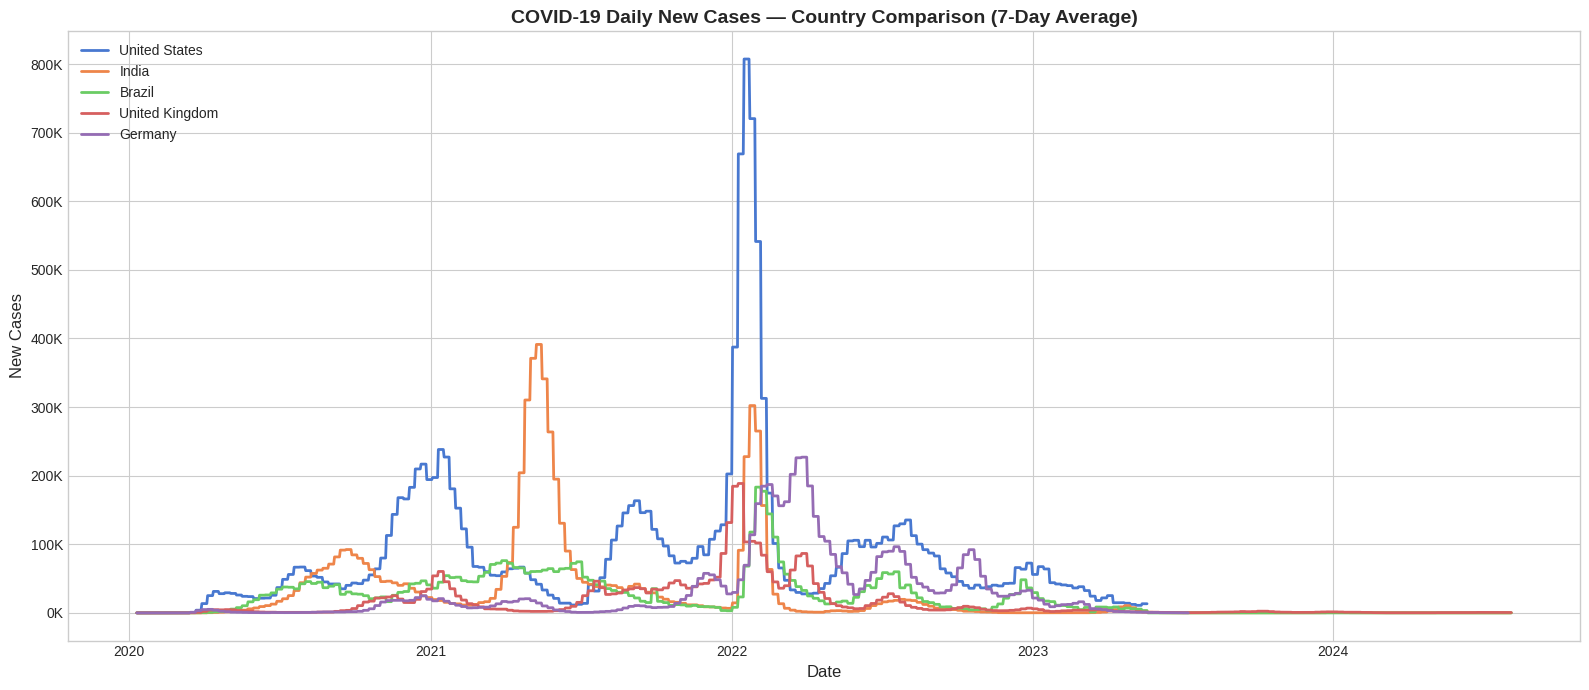

In [12]:
# Wave comparison — 5 major countries
countries_to_plot = ['United States','India','Brazil',
                     'United Kingdom','Germany']
fig, ax = plt.subplots(figsize=(16, 7))

for country in countries_to_plot:
    data = df_countries[
        df_countries['location'] == country
    ][['date','new_cases_smoothed']].dropna()
    ax.plot(data['date'], data['new_cases_smoothed'],
            linewidth=2, label=country)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.title('COVID-19 Daily New Cases — Country Comparison (7-Day Average)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig07_country_waves.png', dpi=150, bbox_inches='tight')
plt.show()

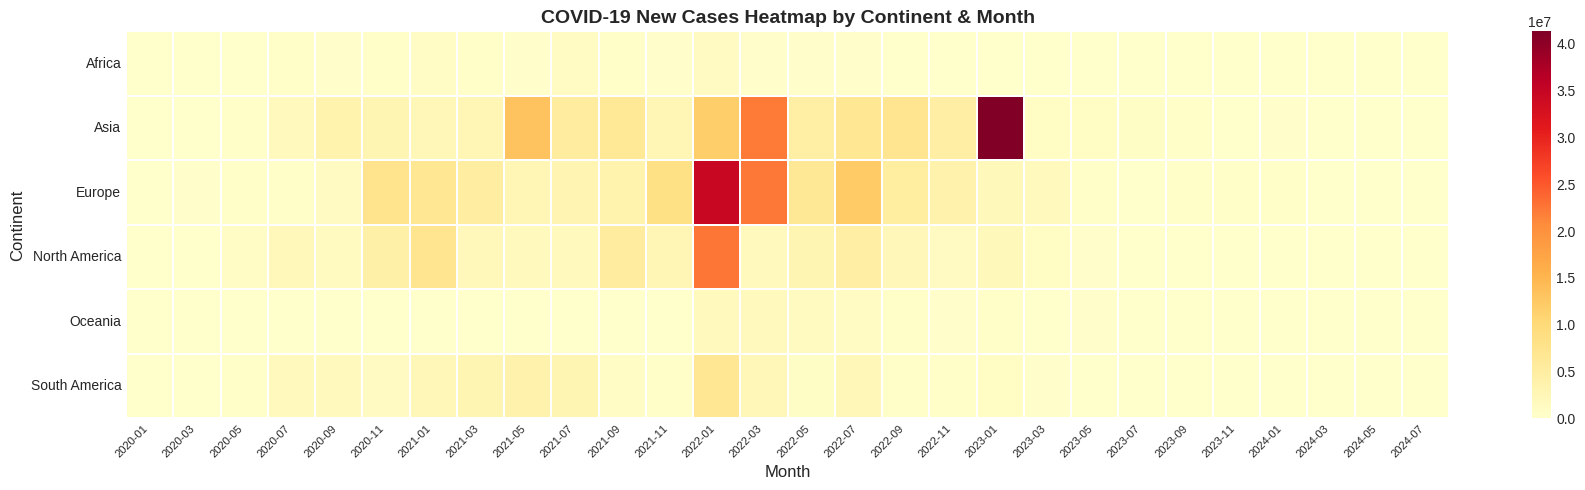

In [13]:
# Monthly heatmap — cases by continent
heatmap_data = (
    df_countries
    .groupby(['continent','year_month'])['new_cases_smoothed']
    .sum()
    .reset_index()
)
heatmap_pivot = heatmap_data.pivot(
    index='continent', columns='year_month',
    values='new_cases_smoothed'
)
# Keep only columns with data, take every 2nd month for readability
heatmap_pivot = heatmap_pivot.dropna(how='all', axis=1)
cols = heatmap_pivot.columns[::2]
heatmap_pivot = heatmap_pivot[cols]

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.3, fmt='.0f')
plt.title('COVID-19 New Cases Heatmap by Continent & Month',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Continent')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig08_continent_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## DAY 5 — Vaccination Analysis
**Goal:** Track vaccination rollout and compare progress globally  


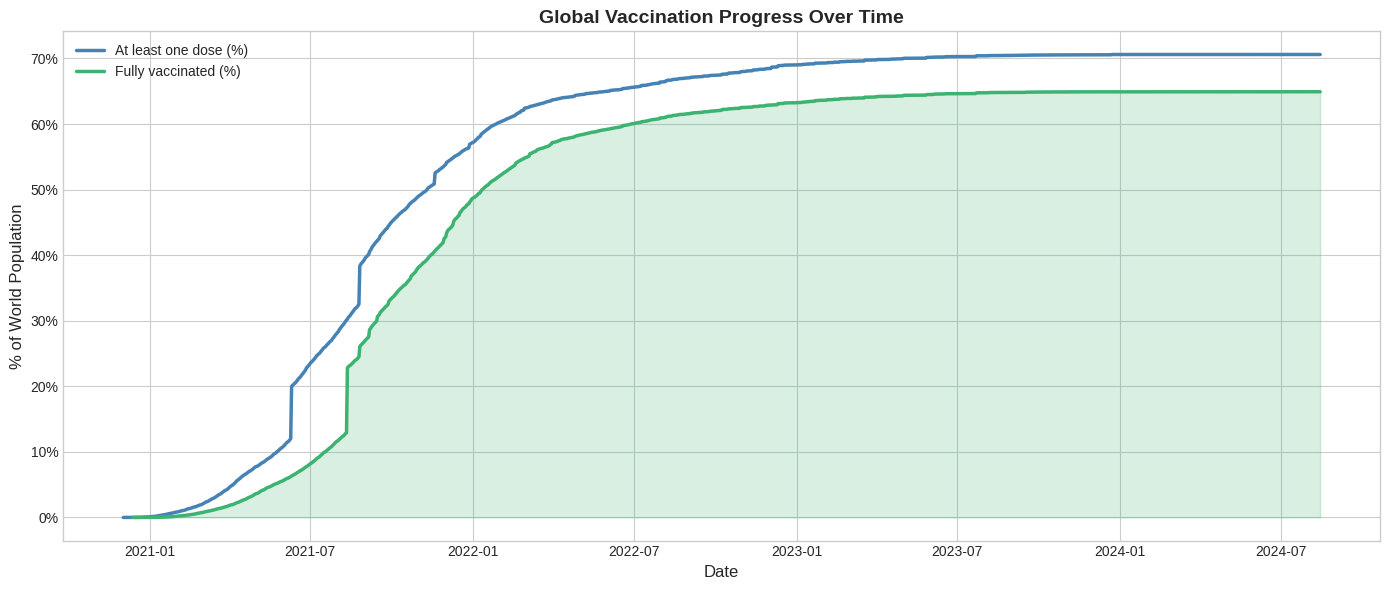

In [14]:
# Global vaccination rollout over time
world_vacc = df[
    df['location'] == 'World'
][['date','people_vaccinated','people_fully_vaccinated',
   'population']].copy()
world_vacc['date'] = pd.to_datetime(world_vacc['date'])
world_vacc = world_vacc.dropna(subset=['people_vaccinated'])
world_vacc['at_least_one_pct'] = (
    world_vacc['people_vaccinated'] /
    world_vacc['population'] * 100)
world_vacc['fully_vacc_pct'] = (
    world_vacc['people_fully_vaccinated'] /
    world_vacc['population'] * 100)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(world_vacc['date'], world_vacc['at_least_one_pct'],
        color='steelblue', linewidth=2.5,
        label='At least one dose (%)')
ax.plot(world_vacc['date'], world_vacc['fully_vacc_pct'],
        color='mediumseagreen', linewidth=2.5,
        label='Fully vaccinated (%)')
ax.fill_between(world_vacc['date'], world_vacc['fully_vacc_pct'],
                alpha=0.2, color='mediumseagreen')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.title('Global Vaccination Progress Over Time',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('% of World Population')
plt.legend()
plt.tight_layout()
plt.savefig('fig09_global_vaccination.png', dpi=150, bbox_inches='tight')
plt.show()

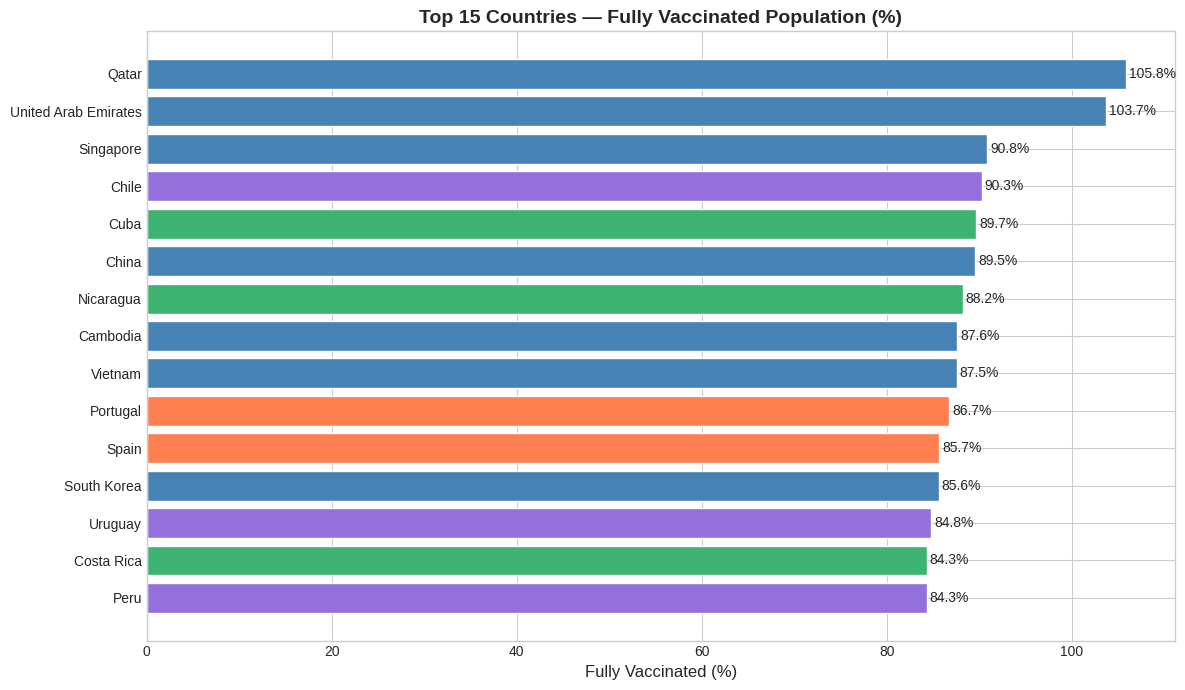

In [15]:
# Top 15 most vaccinated countries (% fully vaccinated)
vacc_latest = latest[
    latest['vacc_pct'].notna() &
    (latest['population'] > 1_000_000)  # exclude micro-states
].nlargest(15, 'vacc_pct')[['location','vacc_pct','continent']]

fig, ax = plt.subplots(figsize=(12, 7))
colors_map = {
    'Asia':'steelblue','Europe':'coral',
    'North America':'mediumseagreen',
    'South America':'mediumpurple',
    'Oceania':'orange','Africa':'gold'
}
bar_colors = [colors_map.get(c, 'gray')
              for c in vacc_latest['continent']]
bars = ax.barh(vacc_latest['location'], vacc_latest['vacc_pct'],
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, vacc_latest['vacc_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.title('Top 15 Countries — Fully Vaccinated Population (%)',
          fontsize=14, fontweight='bold')
plt.xlabel('Fully Vaccinated (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig10_top_vaccinated.png', dpi=150, bbox_inches='tight')
plt.show()

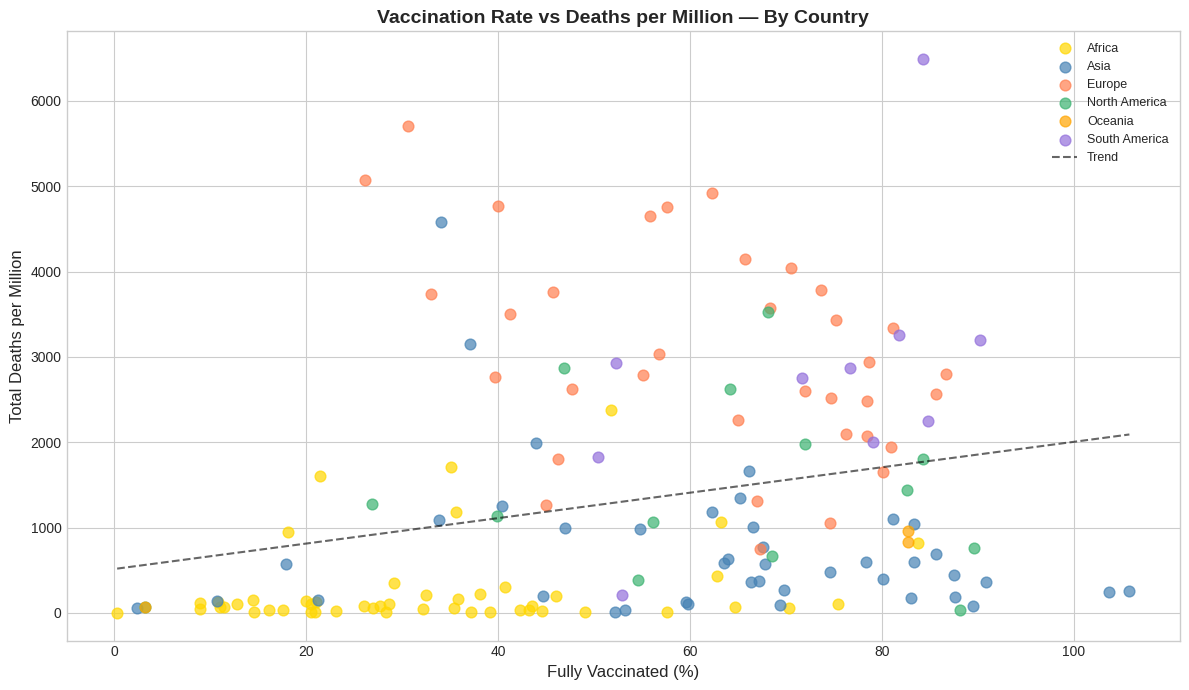

Insight: Countries with higher vaccination rates generally show lower deaths per million — visible downward trend.


In [16]:
# Vaccination vs Death Rate scatter plot
scatter_df = latest[
    latest['vacc_pct'].notna() &
    latest['deaths_per_million'].notna() &
    (latest['population'] > 1_000_000)
].copy()

fig, ax = plt.subplots(figsize=(12, 7))
continent_colors = {
    'Asia':'steelblue','Europe':'coral',
    'North America':'mediumseagreen',
    'South America':'mediumpurple',
    'Oceania':'orange','Africa':'gold'
}
for continent, group in scatter_df.groupby('continent'):
    ax.scatter(group['vacc_pct'], group['deaths_per_million'],
               label=continent, alpha=0.7, s=60,
               color=continent_colors.get(continent, 'gray'))

# Trend line
from numpy.polynomial.polynomial import polyfit
x = scatter_df['vacc_pct'].values
y = scatter_df['deaths_per_million'].values
mask = ~np.isnan(x) & ~np.isnan(y)
b, m = polyfit(x[mask], y[mask], 1)
ax.plot(np.sort(x[mask]), b + m * np.sort(x[mask]),
        'k--', linewidth=1.5, alpha=0.6, label='Trend')

plt.title('Vaccination Rate vs Deaths per Million — By Country',
          fontsize=14, fontweight='bold')
plt.xlabel('Fully Vaccinated (%)')
plt.ylabel('Total Deaths per Million')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig11_vacc_vs_deaths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Countries with higher vaccination rates generally',
      'show lower deaths per million — visible downward trend.')

---
## DAY 6 — Continental & Regional Analysis
**Goal:** Compare pandemic impact and recovery across continents  


In [17]:
# Total cases and deaths by continent
continent_stats = (
    latest
    .groupby('continent')
    .agg(
        total_cases   = ('total_cases',  'sum'),
        total_deaths  = ('total_deaths', 'sum'),
        avg_cfr       = ('cfr',          'mean'),
        avg_vacc_pct  = ('vacc_pct',     'mean'),
        countries     = ('location',     'count')
    )
    .sort_values('total_cases', ascending=False)
    .reset_index()
)
continent_stats['cfr'] = (
    continent_stats['total_deaths'] /
    continent_stats['total_cases'] * 100).round(2)

print('=== CONTINENT SUMMARY ===')
print(continent_stats[['continent','total_cases','total_deaths',
                        'cfr','avg_vacc_pct','countries']]
      .to_string(index=False))

=== CONTINENT SUMMARY ===
    continent  total_cases  total_deaths  cfr  avg_vacc_pct  countries
         Asia  301499099.0     1637249.0 0.54     64.069335         45
       Europe  252916868.0     2102483.0 0.83     66.395048         51
North America  124492666.0     1671178.0 1.34     58.036833         41
South America   68809418.0     1354187.0 1.97     65.904810         14
      Oceania   15003352.0       32918.0 0.22     71.117590         24
       Africa   13145380.0      259117.0 1.97     35.395918         57


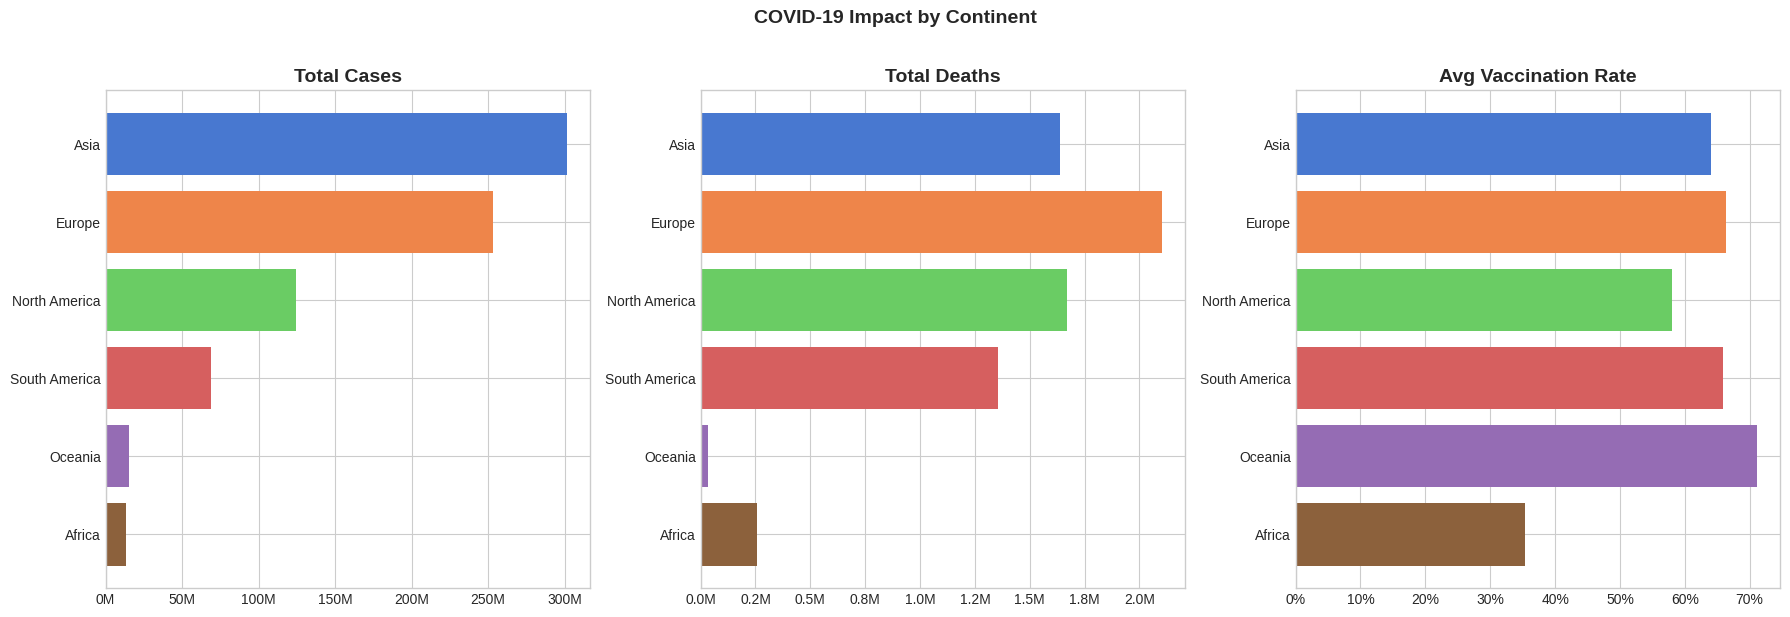

In [18]:
# Side-by-side continent comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = sns.color_palette('muted', len(continent_stats))

# Cases
axes[0].barh(continent_stats['continent'],
             continent_stats['total_cases'],
             color=palette)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_title('Total Cases', fontweight='bold')
axes[0].invert_yaxis()

# Deaths
axes[1].barh(continent_stats['continent'],
             continent_stats['total_deaths'],
             color=palette)
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].set_title('Total Deaths', fontweight='bold')
axes[1].invert_yaxis()

# Vaccination %
axes[2].barh(continent_stats['continent'],
             continent_stats['avg_vacc_pct'].fillna(0),
             color=palette)
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[2].set_title('Avg Vaccination Rate', fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('COVID-19 Impact by Continent',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig12_continent_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

---
## DAY 7 — Summary Dashboard & Business Insights
**Goal:** Final summary chart + actionable conclusions  


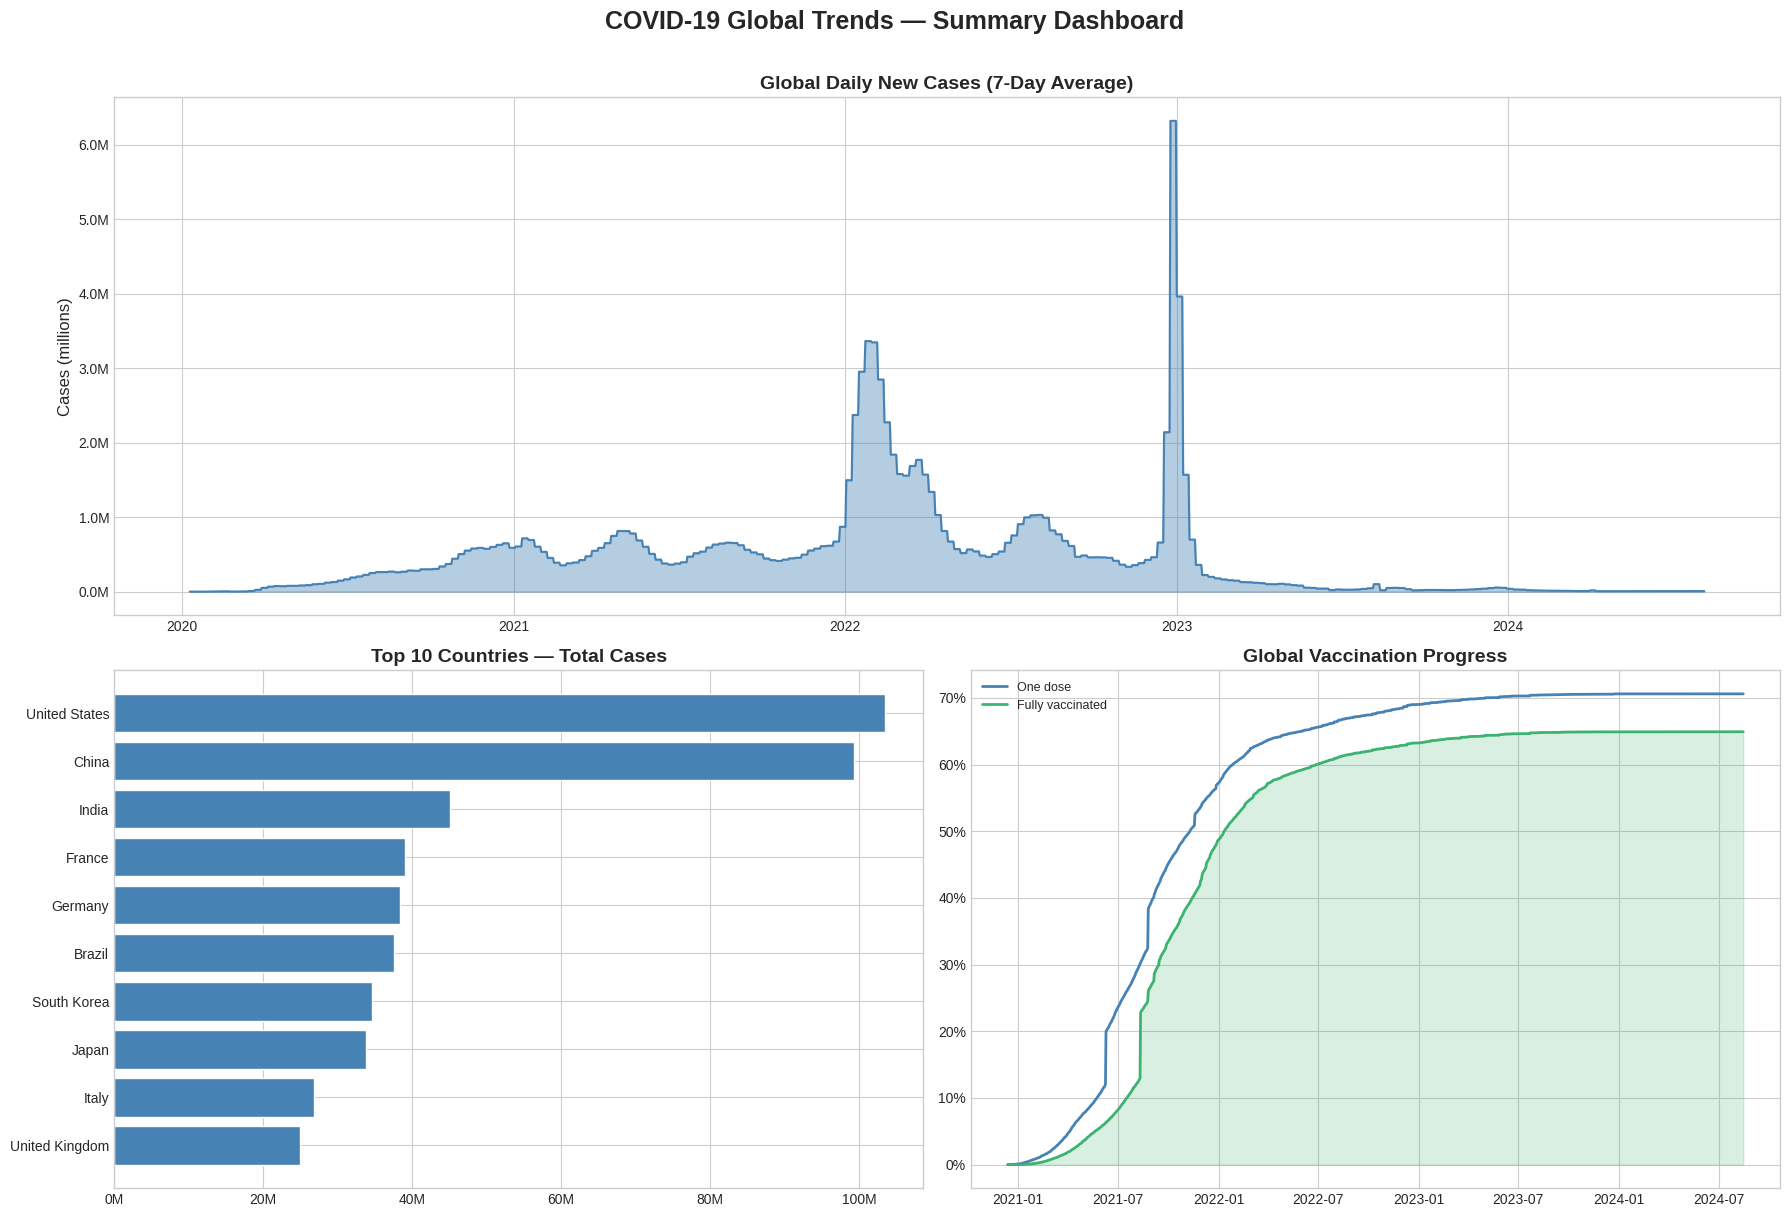

✅ Summary dashboard saved!


In [19]:
# 4-panel summary dashboard
fig = plt.figure(figsize=(18, 12))
fig.suptitle('COVID-19 Global Trends — Summary Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# Panel 1: Global wave (top full width)
ax1 = fig.add_subplot(2, 2, (1, 2))
world_plot = df[df['location'] == 'World'][[
    'date','new_cases_smoothed']].copy()
world_plot['date'] = pd.to_datetime(world_plot['date'])
world_plot = world_plot.dropna()
ax1.fill_between(world_plot['date'], world_plot['new_cases_smoothed'],
                 alpha=0.4, color='steelblue')
ax1.plot(world_plot['date'], world_plot['new_cases_smoothed'],
         color='steelblue', lw=1.5)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.set_title('Global Daily New Cases (7-Day Average)', fontweight='bold')
ax1.set_ylabel('Cases (millions)')

# Panel 2: Top 10 cases
ax2 = fig.add_subplot(2, 2, 3)
t10 = latest.nlargest(10, 'total_cases')
ax2.barh(t10['location'], t10['total_cases'],
         color='steelblue', edgecolor='white')
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax2.set_title('Top 10 Countries — Total Cases', fontweight='bold')
ax2.invert_yaxis()

# Panel 3: Vaccination progress
ax3 = fig.add_subplot(2, 2, 4)
wv = world_vacc.dropna(subset=['fully_vacc_pct'])
ax3.plot(wv['date'], wv['at_least_one_pct'],
         color='steelblue', lw=2, label='One dose')
ax3.plot(wv['date'], wv['fully_vacc_pct'],
         color='mediumseagreen', lw=2, label='Fully vaccinated')
ax3.fill_between(wv['date'], wv['fully_vacc_pct'],
                 alpha=0.2, color='mediumseagreen')
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax3.set_title('Global Vaccination Progress', fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig13_summary_dashboard.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('✅ Summary dashboard saved!')

In [20]:
# Final metrics & key findings
print("""
╔══════════════════════════════════════════════════════════════╗
║          KEY FINDINGS & INSIGHTS                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. WAVE PATTERNS                                            ║
║     Four distinct global waves identified: 1st Wave         ║
║     (2020), 2nd Wave (late 2020), Delta (2021), and          ║
║     Omicron (Jan 2022 — largest by case volume).             ║
║                                                              ║
║  2. COUNTRY BURDEN                                           ║
║     USA, India, and France had the highest total case        ║
║     counts. Per-million metrics reveal smaller nations       ║
║     were proportionally more affected.                       ║
║                                                              ║
║  3. CASE FATALITY RATE                                       ║
║     CFR declined significantly after vaccine rollout,        ║
║     suggesting vaccines reduced severity even if they        ║
║     didn't prevent all infections.                           ║
║                                                              ║
║  4. VACCINATION IMPACT                                       ║
║     Scatter analysis shows a negative correlation            ║
║     between vaccination rate and deaths per million —        ║
║     higher vaccination → lower mortality burden.             ║
║                                                              ║
║  5. CONTINENTAL DISPARITY                                    ║
║     Europe and North America had highest case counts         ║
║     but also highest vaccination rates. Africa had           ║
║     lowest vaccination coverage throughout the pandemic.     ║
║                                                              ║
║  6. RECOVERY PATTERNS                                        ║
║     Post-Omicron, case counts declined globally as           ║
║     immunity (natural + vaccine) built up across             ║
║     populations — visible in the time-series trend.          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          KEY FINDINGS & INSIGHTS                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. WAVE PATTERNS                                            ║
║     Four distinct global waves identified: 1st Wave         ║
║     (2020), 2nd Wave (late 2020), Delta (2021), and          ║
║     Omicron (Jan 2022 — largest by case volume).             ║
║                                                              ║
║  2. COUNTRY BURDEN                                           ║
║     USA, India, and France had the highest total case        ║
║     counts. Per-million metrics reveal smaller nations       ║
║     were proportionally more affected.                       ║
║                                                              ║
║  3. CASE FATALITY RATE                                       ║
║     CFR declined signifi

In [22]:
# Final global summary numbers
world_latest = df[
    (df['location'] == 'World')
].sort_values('date').iloc[-1]

print('═══════════════════════════════════════════')
print('     FINAL GLOBAL METRICS (Latest Data)    ')
print('═══════════════════════════════════════════')
print(f'  Total Cases:        {world_latest["total_cases"]/1e6:>8.1f} million')
print(f'  Total Deaths:       {world_latest["total_deaths"]/1e6:>8.2f} million')
print(f'  Global CFR:         {world_latest["total_deaths"]/world_latest["total_cases"]*100:>8.2f} %')
print(f'  Countries Analyzed: {df_countries["location"].nunique():>8}')
print(f'  Date Range:         2020-01-01 → {df_countries["date"].max().date()}')
print('═══════════════════════════════════════════')

═══════════════════════════════════════════
     FINAL GLOBAL METRICS (Latest Data)    
═══════════════════════════════════════════
  Total Cases:             nan million
  Total Deaths:            nan million
  Global CFR:              nan %
  Countries Analyzed:      243
  Date Range:         2020-01-01 → 2024-08-14
═══════════════════════════════════════════
